### Objectif métier : détecter les signaux précoces de fragilité
### On construit un score de vigilance qui anticipe un risque de fragilité avant le franchissement des seuils réglementaires.
### L'EDA doit donc répondre à 3 questions :
#### 1) quelle est la structure des données ?
#### 2) quels profils financiers se dégradent progressivement ?
#### 3) quels signaux comportementaux apparaissent avant l'échec réglementaire ?


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# On charge les deux tables brutes générées par data_generation/run_generation.py
clients = pd.read_parquet("../data/raw/clients.parquet")
transactions = pd.read_parquet("../data/raw/transactions.parquet")

# Premier réflexe face à un nouveau dataset : combien de lignes, quelle granularité
print("Table clients :", clients.shape)
print("Table transactions :", transactions.shape)
print()

# La granularité doit être claire avant d'aller plus loin :
# - clients : une ligne = un client
# - transactions : une ligne = un client, pour un mois donné
print("Une ligne de 'clients' = un client")
print("Une ligne de 'transactions' = un client, un mois donné")
print()

# La colonne 'mois' est un index relatif (0 à 17), pas une vraie date calendaire
print("Période couverte : mois", transactions["mois"].min(), "à", transactions["mois"].max())
print()

# Aperçu rapide de la table clients
clients.head(3)

Table clients : (2000, 5)
Table transactions : (36000, 8)

Une ligne de 'clients' = un client
Une ligne de 'transactions' = un client, un mois donné

Période couverte : mois 0 à 17



,client_id,age,statut_pro,anciennete_mois,profil_trajectoire
0,CLI_00001,67,retraite,138,degradation_progressive
1,CLI_00002,28,salarie,24,stable
2,CLI_00003,22,etudiant,77,stable


In [17]:
# On vérifie qu'il n'y a aucune valeur manquante dans les deux tables
print("Valeurs manquantes - clients :")
print(clients.isnull().sum())
print()

print("Valeurs manquantes - transactions :")
print(transactions.isnull().sum())
print()

# On vérifie qu'aucun client n'est dupliqué dans la table clients
print("Doublons de client_id :", clients["client_id"].duplicated().sum())
print()

# On vérifie qu'il n'y a pas deux lignes pour le même client au même mois
print("Doublons (client_id, mois) :", transactions.duplicated(subset=["client_id", "mois"]).sum())

Valeurs manquantes - clients :
client_id             0
age                   0
statut_pro            0
anciennete_mois       0
profil_trajectoire    0
dtype: int64

Valeurs manquantes - transactions :
client_id                0
mois                     0
revenus_entrants         0
depenses_contraintes     0
depenses_variables       0
solde_fin_mois           0
nb_incidents_paiement    0
nb_decouverts            0
dtype: int64

Doublons de client_id : 0

Doublons (client_id, mois) : 0


Répartition par profil :
profil_trajectoire
stable                     0.664
degradation_progressive    0.206
fragile_des_le_depart      0.131

Répartition des statuts par profil :
statut_pro               etudiant  independant  retraite  salarie  sans_emploi
profil_trajectoire                                                            
degradation_progressive        35          101        44      212           19
fragile_des_le_depart          96           42        12       51           61
stable                         77          145       249      831           25

Moyennes mensuelles par profil (premières lignes) :
     profil_trajectoire  mois  revenus_entrants  depenses_contraintes  depenses_variables  solde_fin_mois  nb_incidents_paiement  nb_decouverts
degradation_progressive     0       1890.076131            658.953771         1224.951630     2421.879951               0.068127       0.116788
degradation_progressive     1       1883.579489            658.953771         1221.

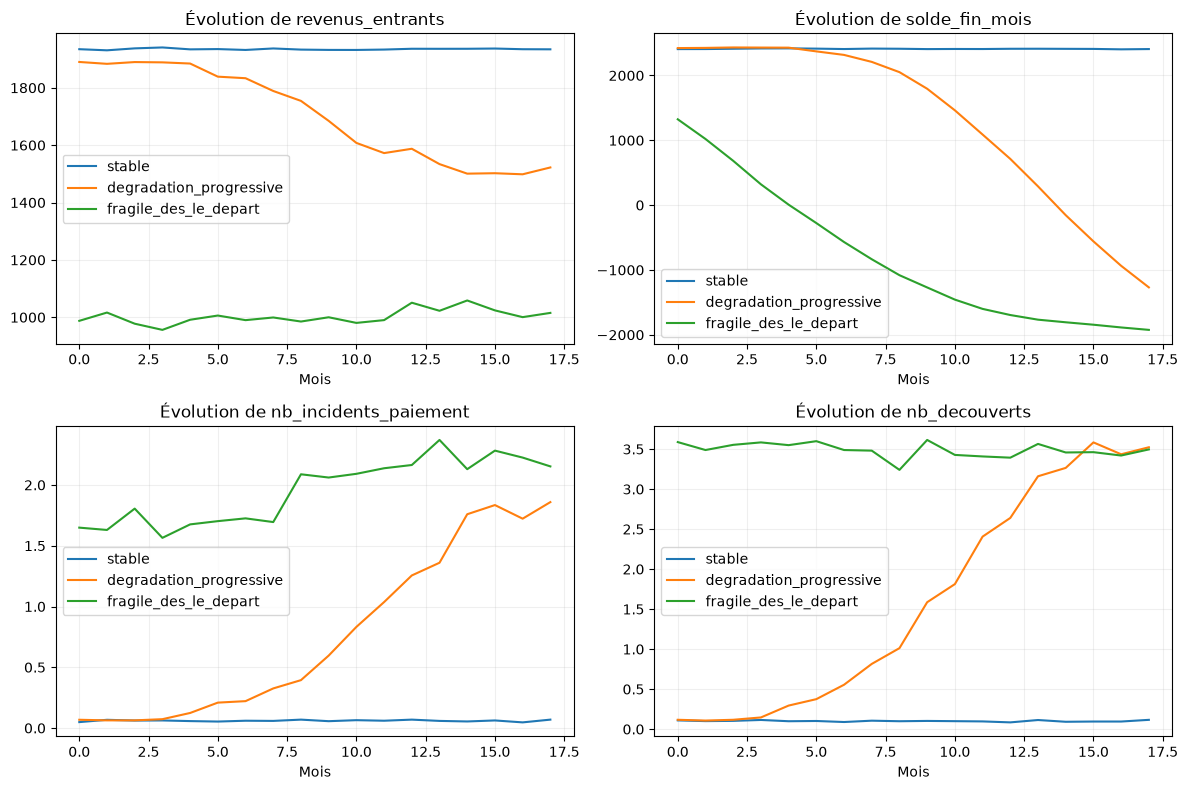

Interprétation métier :
- Le profil stable reste à des niveaux de solde et d'incidents quasi constants.
- Le profil degradation_progressive montre une chute progressive du revenu et du solde avant le franchissement des seuils.
- Le profil fragile_des_le_depart est déjà au-delà du seuil réglementaire dès le début de la période.
- Un bon score de vigilance cible donc la phase de dégradation progressive, avant l'état déjà fragile.


In [19]:
# On mesure la répartition des profils et les dynamiques mensuelles
merged = transactions.merge(
    clients[["client_id", "profil_trajectoire", "statut_pro"]],
    on="client_id",
    how="left",
)

print("Répartition par profil :")
print(clients["profil_trajectoire"].value_counts(normalize=True).round(3).to_string())
print()

print("Répartition des statuts par profil :")
print(clients.groupby("profil_trajectoire")["statut_pro"].value_counts().unstack(fill_value=0).to_string())
print()

# Agrégats mensuels pour comparer les trajectoires de solvabilité
monthly = (
    merged.groupby(["profil_trajectoire", "mois"], as_index=False)
    .agg(
        revenus_entrants=("revenus_entrants", "mean"),
        depenses_contraintes=("depenses_contraintes", "mean"),
        depenses_variables=("depenses_variables", "mean"),
        solde_fin_mois=("solde_fin_mois", "mean"),
        nb_incidents_paiement=("nb_incidents_paiement", "mean"),
        nb_decouverts=("nb_decouverts", "mean"),
    )
)

print("Moyennes mensuelles par profil (premières lignes) :")
print(monthly.head(9).to_string(index=False))
print()

# Pour un client en dégradation progressive, on cherche le signal avant le franchissement des seuils
progression = monthly[monthly["profil_trajectoire"] == "degradation_progressive"].sort_values("mois")
first_period = progression.iloc[:6][["revenus_entrants", "solde_fin_mois", "nb_incidents_paiement", "nb_decouverts"]].mean()
last_period = progression.iloc[-6:][["revenus_entrants", "solde_fin_mois", "nb_incidents_paiement", "nb_decouverts"]].mean()

print("Signal précoce de dégradation progressive :")
print("- 6 premiers mois :")
print(first_period.round(2).to_dict())
print("- 6 derniers mois :")
print(last_period.round(2).to_dict())
print()

# On visualise les trajectoires par profil pour identifier les indicateurs les plus discriminants
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = ["revenus_entrants", "solde_fin_mois", "nb_incidents_paiement", "nb_decouverts"]
profiles = ["stable", "degradation_progressive", "fragile_des_le_depart"]

for ax, metric in zip(axes.flatten(), metrics):
    for profile in profiles:
        subset = monthly[monthly["profil_trajectoire"] == profile].sort_values("mois")
        ax.plot(subset["mois"], subset[metric], label=profile)
    ax.set_title(f"Évolution de {metric}")
    ax.set_xlabel("Mois")
    ax.grid(alpha=0.2)
    ax.legend()

fig.tight_layout()
plt.show()

# Conclusion métier : le signal précoce est le mélange de baisse de revenus, baisse de solde et hausse d'incidents
print("Interprétation métier :")
print("- Le profil stable reste à des niveaux de solde et d'incidents quasi constants.")
print("- Le profil degradation_progressive montre une chute progressive du revenu et du solde avant le franchissement des seuils.")
print("- Le profil fragile_des_le_depart est déjà au-delà du seuil réglementaire dès le début de la période.")
print("- Un bon score de vigilance cible donc la phase de dégradation progressive, avant l'état déjà fragile.")


In [29]:
# 1) Cible métier : target_fragile_j3m
# On veut repérer un client qui n'est pas encore dans le seuil légal,
# mais qui va l'atteindre dans les 3 prochains mois.

transactions = pd.read_parquet("../data/raw/transactions.parquet").sort_values(["client_id", "mois"]).copy()

# --- Définition de fragile_legal, avec le vrai critère légal ---

# Critere principal : 5+ incidents dans le mois, combine a un critere de ressources
# (le vrai critere legal, pas juste "solde negatif")
SEUIL_RESSOURCES_MODESTES = 1500    # a documenter comme hypothese assumee

transactions["critere_incidents_ressources"] = (
    (transactions["nb_incidents_paiement"] >= 5)
    & (transactions["revenus_entrants"] < SEUIL_RESSOURCES_MODESTES)
).astype(int)

# Critere secondaire : au moins un incident pendant 3 mois consecutifs
# (proxy de l'inscription FCC, qu'on ne genere pas explicitement)
transactions["a_incident_ce_mois"] = (transactions["nb_incidents_paiement"] >= 1).astype(int)
transactions["incidents_3_mois_consecutifs"] = (
    transactions.groupby("client_id")["a_incident_ce_mois"]
    .transform(lambda s: s.rolling(3, min_periods=3).sum())
) == 3

transactions["fragile_legal"] = (
    (transactions["critere_incidents_ressources"] == 1)
    | (transactions["incidents_3_mois_consecutifs"])
).astype(int)

# --- Vérification de la nouvelle distribution ---

print("Nouvelle distribution de fragile_legal :")
print(transactions["fragile_legal"].value_counts(normalize=True).round(3))
print()
print("Répartition des deux critères (avant combinaison) :")
print("Critère incidents + ressources :", transactions["critere_incidents_ressources"].mean().round(3))
print("Critère 3 mois consécutifs :", transactions["incidents_3_mois_consecutifs"].mean().round(3))
print()

# --- Construction de la cible target_fragile_j3m (inchangée) ---

for lag in [1, 2, 3]:
    transactions[f"fragile_legal_lag{lag}"] = (
        transactions.groupby("client_id")["fragile_legal"].shift(-lag).fillna(0).astype(int)
    )

transactions["target_fragile_j3m"] = (
    (transactions["fragile_legal"] == 0)
    & (
        (transactions["fragile_legal_lag1"] == 1)
        | (transactions["fragile_legal_lag2"] == 1)
        | (transactions["fragile_legal_lag3"] == 1)
    )
).astype(int)

transactions = transactions[transactions["mois"] <= transactions["mois"].max() - 3].copy()

print("Distribution de la cible target_fragile_j3m :")
print(transactions["target_fragile_j3m"].value_counts(normalize=True).round(3).to_string())
print()
print(transactions[["client_id", "mois", "fragile_legal", "target_fragile_j3m"]].head(12).to_string(index=False))

Nouvelle distribution de fragile_legal :
fragile_legal
0    0.888
1    0.112
Name: proportion, dtype: float64

Répartition des deux critères (avant combinaison) :
Critère incidents + ressources : 0.006
Critère 3 mois consécutifs : 0.11

Distribution de la cible target_fragile_j3m :
target_fragile_j3m
0    0.917
1    0.083

client_id  mois  fragile_legal  target_fragile_j3m
CLI_00001     0              0                   0
CLI_00001     1              0                   0
CLI_00001     2              0                   0
CLI_00001     3              0                   0
CLI_00001     4              0                   0
CLI_00001     5              0                   0
CLI_00001     6              0                   0
CLI_00001     7              0                   0
CLI_00001     8              0                   1
CLI_00001     9              0                   1
CLI_00001    10              0                   1
CLI_00001    11              1                   0


## 2) Features d'alerte comportementales

Les features les plus utiles pour détecter le risque avant la rupture réglementaire sont :
- évolution du solde et du ratio solde/revenu,
- hausse des incidents de paiement et des découverts,
- baisse progressive des revenus et augmentation des dépenses contraintes,
- écarts par rapport aux tendances récentes (rolling 3 et 6 mois),
- variables sociodémographiques utiles comme l'âge et le statut professionnel.

L'objectif est d'identifier la phase de dégradation progressive, pas l'état déjà fragile.


In [26]:
import numpy as np

# 2) Définition des features d'alerte
clients = pd.read_parquet("../data/raw/clients.parquet")
model_df = transactions.merge(
    clients[["client_id", "age", "statut_pro", "anciennete_mois"]],
    on="client_id",
    how="left",
)

for col in [
    "revenus_entrants",
    "depenses_contraintes",
    "depenses_variables",
    "solde_fin_mois",
    "nb_incidents_paiement",
    "nb_decouverts",
]:
    model_df[f"{col}_lag1"] = model_df.groupby("client_id")[col].shift(1).fillna(0)
    model_df[f"{col}_delta"] = model_df.groupby("client_id")[col].diff(1).fillna(0)
    model_df[f"{col}_roll3"] = model_df.groupby("client_id")[col].transform(
        lambda s: s.rolling(3, min_periods=1).mean().fillna(0)
    )
    model_df[f"{col}_roll6"] = model_df.groupby("client_id")[col].transform(
        lambda s: s.rolling(6, min_periods=1).mean().fillna(0)
    )

model_df["solde_to_revenu_ratio"] = (
    model_df["solde_fin_mois"] / model_df["revenus_entrants"].replace(0, np.nan)
).fillna(0)
model_df["tension_financiere"] = (
    model_df["nb_incidents_paiement"]
    + 1.5 * model_df["nb_decouverts"]
    - 0.001 * model_df["solde_fin_mois"]
)

# Encodage des catégories utiles pour le modèle.
model_df = pd.get_dummies(model_df, columns=["statut_pro"], prefix="statut", drop_first=True)

print("Aperçu des features créées :")
print(model_df[[
    "client_id", "mois", "solde_fin_mois", "solde_to_revenu_ratio",
    "nb_incidents_paiement", "nb_decouverts", "tension_financiere",
    "target_fragile_j3m"
]].head(10).to_string(index=False))


Aperçu des features créées :
client_id  mois  solde_fin_mois  solde_to_revenu_ratio  nb_incidents_paiement  nb_decouverts  tension_financiere  target_fragile_j3m
CLI_00001     0         2026.46               1.267520                      1              0            -1.02646                   0
CLI_00001     1         2107.87               1.406897                      0              1            -0.60787                   0
CLI_00001     2         2180.65               1.347444                      0              0            -2.18065                   0
CLI_00001     3         1903.84               1.444941                      0              1            -0.40384                   0
CLI_00001     4         2064.49               1.241358                      1              1             0.43551                   0
CLI_00001     5         1981.09               1.334202                      2              1             1.51891                   0
CLI_00001     6         2117.11         

## 3) Préparation du dataset pour le modèle

Le dataset final est au niveau client-mois : chaque ligne correspond à un client à un mois M, avec ses features comportementales et la cible d'anticipation sur les 3 prochains mois.

Le split doit être temporel :
- train : premiers mois, par exemple mois 0 à 11
- test : derniers mois, par exemple 12 à 15

Cela évite la fuite d'information entre données du futur et du présent.


In [27]:
# 3) Préparation du dataset pour le modèle
# Split temporel, pas aléatoire, pour préserver la logique métier.
train_df = model_df[model_df["mois"] < 12].copy()
test_df = model_df[model_df["mois"] >= 12].copy()

feature_cols = [
    c for c in model_df.columns
    if c not in [
        "client_id",
        "mois",
        "fragile_legal",
        "fragile_legal_lag1",
        "fragile_legal_lag2",
        "fragile_legal_lag3",
        "target_fragile_j3m",
    ]
]

X_train = train_df[feature_cols]
y_train = train_df["target_fragile_j3m"]
X_test = test_df[feature_cols]
y_test = test_df["target_fragile_j3m"]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Taux positif train:", round(y_train.mean(), 3))
print("Taux positif test:", round(y_test.mean(), 3))


Train shape: (24000, 38) (24000,)
Test shape: (6000, 38) (6000,)
Taux positif train: 0.062
Taux positif test: 0.132
